# Python'da Kütüphaneler + Test + Hata Yönetimi 

---
## 1) Kütüphane / Modül / Paket mantığı 

- **Modül**: Tek `.py` dosyası (örn. `math`, `random`)
- **Paket**: Klasör + modüller (örn. `pathlib`, `json`)
- **3. parti**: `pip install ...` ile kurulur (örn. `requests`, `pandas`)

Neden kullanırız?
- yeniden yazmamak
- daha güvenilir (çok test edilmiş)
- okunabilirlik ve bakım kolaylığı


In [7]:
import sys, math, pathlib, json, re, statistics
print("Python:", sys.version.split()[0])
print("math.pi:", math.pi)
print("Path örneği:", pathlib.Path("."))
print("regex sayı var mı?:", bool(re.search(r"\d+", "abc123")))
print("mean:", statistics.mean([10, 20, 30,100]))
print("std:",statistics.stdev([1.75,1.52,1.63,1.64,1.58]))
print("std:",statistics.stdev([10,20,30,100]))

Python: 3.10.12
math.pi: 3.141592653589793
Path örneği: .
regex sayı var mı?: True
mean: 40
std: 0.08502940667792523
std: 40.824829046386306


### Basit kullanım senaryosu
- Hesaplama: `math`
- Dosya/klasör: `pathlib`
- Ayar dosyası: `json`
- Metin temizleme: `re`
- İstatistik: `statistics`

### Şimdi sıra sizde ✅
1) `random` içe aktarın  
2) 10 kez zar atıp frekans sayın


In [21]:
# TODO: random import
# TODO: 100 zar atıp frekans say
import random

frekanslar=[0,0,0,0,0,0]
for i in range(100):
    tutulan=random.randint(1,6)
    frekanslar[tutulan-1]+=1

print(frekanslar)
    



[14, 17, 17, 16, 18, 18]


---
## 2) Import stilleri 

- `import math` → `math.sqrt(9)` (net ama uzun)
- `from math import sqrt` → `sqrt(9)` (kısa ama çakışabilir)
- `import datetime as dt` (takma ad)


In [26]:
import math
from math import cos,sin
import datetime as dt


print(math.sqrt(16))
print(cos(90))
print(sin(90))
print(dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

4.0
-0.4480736161291701
0.8939966636005579
2025-12-17 19:32:02


### Şimdi sıra sizde ✅
`statistics` modülünü `st` takma adıyla içe aktarın ve mean/median hesaplayın.


In [30]:
# TODO: import statistics as st
# TODO: mean/median hesapla
import statistics as st 
import random 

listem=[random.randint(1,50) for i in range(50)]
print(listem)
print(st.mean([30,40,50]))
print(st.mean(listem))
print(st.median(listem))



[42, 22, 4, 9, 45, 49, 50, 36, 14, 2, 41, 6, 8, 50, 42, 23, 34, 21, 35, 26, 39, 40, 44, 19, 3, 17, 40, 8, 11, 45, 21, 33, 48, 25, 10, 43, 41, 1, 19, 32, 8, 15, 20, 48, 35, 13, 11, 31, 18, 26]
40
26.46
25.5


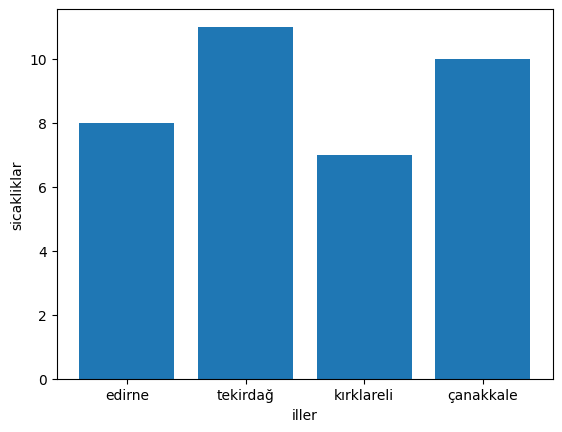

In [3]:
#sütun grafiği çizdirme
import matplotlib.pyplot as plt
iller=["edirne","tekirdağ","kırklareli","çanakkale"]
sicakliklar=[8,11,7,10]

plt.bar(iller,sicakliklar)
plt.xlabel("iller")
plt.ylabel("sicakliklar")
plt.show()


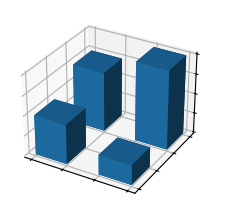

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

# Make data
x = [1, 1, 2, 2]
y = [1, 2, 1, 2]
z = [0, 0, 0, 0]
dx = np.ones_like(x)*0.5
dy = np.ones_like(x)*0.5
dz = [2, 3, 1, 4]

# Plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.bar3d(x, y, z, dx, dy, dz)
ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])

plt.show()

---
## 3) Kütüphane seçimi 

Kriterler:
- ihtiyaç
- standart kütüphane yeter mi?
- bakım/dokümantasyon
- güvenlik
- performans
- bağımlılık sayısı


### Şimdi sıra sizde ✅
1) 2MB CSV → hangi kütüphane?  
2) 2GB CSV analizi → hangi kütüphane?  
3) API isteği → hangi kütüphane?  
4) Test → hangi kütüphane?


**Cevaplarım (öğrenci):**
- 1) ...
- 2) ...
- 3) ...
- 4) ...


---
## 4) Bol örnek + basit kullanım senaryosu

Her örnek:
- Amaç
- Neden bu kütüphane?
- Kod
- Senaryo
- Şimdi sıra sizde ✅


### 4.1 `pathlib` ile dosya birleştirme

**Amaç:** klasördeki `.txt` dosyalarını birleştirmek.  
**Neden:** Path ile okunabilir/taşınabilir yol işlemleri.


In [ ]:
from pathlib import Path

work = Path("ornek_klasor_v2")
work.mkdir(exist_ok=True)

(work/"a.txt").write_text("Merhaba\n", encoding="utf-8")
(work/"b.txt").write_text("Dünya\n", encoding="utf-8")

files = sorted(work.glob("*.txt"))
combined = "".join(p.read_text(encoding="utf-8") for p in files)
print([p.name for p in files])
print(combined)

['a.txt', 'b.txt']
Merhaba
Dünya



In [ ]:
from pathlib import Path

adres="/home/serkan/Belgeler/bilsem2526/OYG1A1/programlama/isimler.txt"
baglanti=open(adres,mode="r",encoding="utf-8")
metin=baglanti.read()
baglanti.close()
print(metin)

isimler=metin.split(",")
# 1- progrmalama içine yoksa "isimler" adında klasör oluştur
# 2- isimler.txt içindeki her isim için bu isimler klasörüne aynı isimle txt dosyalarını oluşturun.

# 

work = Path("isimler")
work.mkdir(exist_ok=True)
for isim in isimler:
    print(isim)
    (work/f"{isim}.txt").write_text(f"{isim}", encoding="utf-8")


girayhan,deniz,çağan,haktan,serkan
girayhan
deniz
çağan
haktan
serkan


**Senaryo:** “Öğrenci cevaplarını tek raporda toplama.”

### Şimdi sıra sizde ✅
c.txt ekleyin, dosya adını başlık yaparak birleştirin ve rapor.txt'ye yazın.


In [14]:
# TODO: c.txt oluştur
# TODO: başlıklı birleştir
# TODO: rapor.txt yaz



### 4.2 `json` ile ayar dosyası

**Amaç:** ayarları dosyaya kaydet/geri yükle.  
**Neden:** insan okunur, standart format.


In [ ]:
import json
from pathlib import Path

settings = {"theme":"dark","font_size":14,"language":"tr","auto_save":True}
cfg = pathlib.Path("settings_v3.json")
cfg.write_text(json.dumps(settings, ensure_ascii=False, indent=2), encoding="utf-8")

loaded = json.loads(cfg.read_text(encoding="utf-8"))
print(loaded)

{'theme': 'dark', 'font_size': 14, 'language': 'tr', 'auto_save': True}


**Senaryo:** “Uygulama açılışta ayarları okur; değişince kaydeder.”

### Şimdi sıra sizde ✅
recent_files ekleyin, font_size +2 yapıp tekrar kaydedin.


In [ ]:
# TODO: recent_files ekle
# TODO: oku -> font_size +2 -> kaydet



### 4.3 `re` ile e-posta maskeleme

**Amaç:** e-posta yakala ve gizle.  
**Neden:** serbest metinde desen yakalama.


In [26]:
import re
text = "ali@example.com, ali+test@site.org, ayse.kaya@uni.edu.tr, test.test,test@,test@sdadas.af"
pattern = r"[\w.+-]+@[\w.-]+\.[A-Za-z]{2,}"
emails = re.findall(pattern, text)

def mask(mail):
    user, domain = mail.split("@",1)
    return user[:2] + "***@" + domain

masked = text
for m in text.split(","):
    # masked = masked.replace(m, mask(m))
    print(m,bool(re.search(pattern,m)))

print(emails)
print(masked)

ali@example.com True
 ali+test@site.org True
 ayse.kaya@uni.edu.tr True
 test.test False
test@ False
test@sdadas.af True
['ali@example.com', 'ali+test@site.org', 'ayse.kaya@uni.edu.tr', 'test@sdadas.af']
ali@example.com, ali+test@site.org, ayse.kaya@uni.edu.tr, test.test,test@,test@sdadas.af


**Senaryo:** “Log’a yazmadan önce kişisel veriyi maskeleme.”

### Şimdi sıra sizde ✅
Telefon numarası yakalamayı deneyin (basit): 05xx xxx xx xx


In [ ]:
# TODO: telefon regex yaz ve dene



### 4.4 `csv` + `statistics` ile not raporu

**Amaç:** CSV'den notları okuyup ortalama/medyan hesaplamak.  


In [ ]:
from pathlib import Path
import csv, statistics

p = Path("notlar_v3.csv")
rows = [["isim","not"],["Ali","70"],["Ayşe","45"],["Mehmet","90"],["Zeynep","55"]]
with open(p,"w",newline="",encoding="utf-8") as f:
    csv.writer(f).writerows(rows)

data=[]
with open(p,"r",encoding="utf-8") as f:
    for row in csv.DictReader(f):
        data.append((row["isim"], int(row["not"])))

grades=[g for _,g in data]
print("mean:", statistics.mean(grades), "median:", statistics.median(grades))

**Senaryo:** “Öğretmen CSV'yi verir; program rapor üretir.”

### Şimdi sıra sizde ✅
>=50 geçenleri ve kalanları listeleyin.


In [ ]:
# TODO: geçen/kalan listesi üret



---
## 5) TRY/EXCEPT Cookbook (çok senaryo) (e, f)

Bu bölümde amaç: en sık hata türlerini tanımak ve **kontrollü** yönetmek.
Her örnekte `errors` listesine kayıt alınır.


### 5.1 Dosya yok (FileNotFoundError) + else/finally

In [29]:
from pathlib import Path
errors=[]
p=Path("yok.txt")

try:
    s = p.read_text(encoding="utf-8")
except FileNotFoundError as e:
    errors.append({"type": type(e).__name__, "where": str(p), "message": "Dosya bulunamadı"})
    s = ""
else:
    print("Okundu, uzunluk:", len(s))
finally:
    print("Deneme bitti")

print("errors:", errors)

Deneme bitti
errors: [{'type': 'FileNotFoundError', 'where': 'yok.txt', 'message': 'Dosya bulunamadı'}]


### Şimdi sıra sizde ✅
Dosyayı oluşturun, tekrar çalıştırın ve else bloğunun çalıştığını doğrulayın.


In [ ]:
# TODO: yok.txt oluştur ve tekrar dene



### 5.2 Tip dönüşümü (ValueError): int olmazsa float dene

In [ ]:
errors=[]
inputs=["12"," 7 ","3.14","abc","", "1e-3"]

def parse_number(s):
    s=s.strip()
    if s=="":
        raise ValueError("Boş giriş")
    try:
        return int(s)
    except ValueError:
        return float(s)

vals=[]
for s in inputs:
    try:
        vals.append(parse_number(s))
    except Exception as e:
        errors.append({"type": type(e).__name__, "value": repr(s), "message": str(e)})

print("vals:", vals)
print("errors:", errors)

### Şimdi sıra sizde ✅
`parse_number` içine aralık kontrolü ekleyin: sayı 0-1000 değilse ValueError fırlatsın.


In [ ]:
# TODO: aralık kontrolü ekle ve test et



### 5.3 KeyError: sözlükte anahtar yok

In [ ]:
errors=[]
user={"name":"Ali","age":21}
try:
    email=user["email"]
except KeyError as e:
    errors.append({"type": type(e).__name__, "missing":"email"})
    email="unknown@example.com"

email2=user.get("email","unknown@example.com")
print(email, email2, errors)

### Şimdi sıra sizde ✅
Hangi yaklaşım daha okunabilir? 1-2 cümle yazın.


In [ ]:
# TODO: yorum yaz (print veya markdown)



### 5.4 JSON bozuk (JSONDecodeError)

In [ ]:
import json
errors=[]
bad='{"a":1,"b":}'
try:
    obj=json.loads(bad)
except json.JSONDecodeError as e:
    errors.append({"type": type(e).__name__, "pos": e.pos, "message":"JSON bozuk"})
    obj={}
print(obj, errors)

### Şimdi sıra sizde ✅
Bozuk JSON'u düzeltin ve hatasız okunduğunu görün.


In [ ]:
# TODO: bad stringini düzeltip loads dene



### 5.5 IndexError: liste sınırı

In [ ]:
errors=[]
items=["elma","armut"]
idx=5
try:
    v=items[idx]
except IndexError as e:
    errors.append({"type": type(e).__name__, "idx": idx, "len": len(items)})
    v=None
print(v, errors)

### Şimdi sıra sizde ✅
try/except yerine indeks kontrolü ile güvenli çözüm yazın.


In [ ]:
# TODO: indeks kontrolü ile çöz



### 5.6 Çoklu except: farklı hatalara farklı mesaj

In [ ]:
from pathlib import Path
errors=[]
p=Path("belki.txt")
try:
    _=p.read_text(encoding="utf-8")
except FileNotFoundError:
    errors.append({"type":"FileNotFoundError","message":"Dosya yok"})
except PermissionError:
    errors.append({"type":"PermissionError","message":"Erişim yok"})
except Exception as e:
    errors.append({"type": type(e).__name__, "message": str(e)})
print(errors)

### Şimdi sıra sizde ✅
Dosya yoksa otomatik oluşturup tekrar okumayı deneyin.


In [ ]:
# TODO: yoksa oluştur, sonra oku (try/except içinde)



### 5.7 Özel hata (Custom Exception)

In [ ]:
errors=[]
class GradeOutOfRangeError(ValueError): ...
def validate_grade(g):
    if not isinstance(g,(int,float)):
        raise TypeError("Not sayı olmalı")
    if not (0<=g<=100):
        raise GradeOutOfRangeError(f"Not aralık dışı: {g}")
    return g

for g in [70,"AA",-3,150,50]:
    try:
        print("OK", validate_grade(g))
    except TypeError as e:
        errors.append({"type":"TypeError","value": g, "message": str(e)})
    except GradeOutOfRangeError as e:
        errors.append({"type":"GradeOutOfRangeError","value": g, "message": str(e)})
print("errors:", errors)

### Şimdi sıra sizde ✅
Hata kayıtlarına `severity` alanı ekleyin: TypeError=error, aralık hatası=warning gibi.


In [ ]:
# TODO: severity ekle



### 5.8 Retry (yeniden dene) - simülasyon

In [ ]:
import random, time
errors=[]
def sometimes_fails():
    if random.random()<0.6:
        raise ConnectionError("Geçici sorun")
    return "OK"

max_tries=5
for attempt in range(1,max_tries+1):
    try:
        r=sometimes_fails()
        print("Başarılı:", r, "attempt:", attempt)
        break
    except ConnectionError as e:
        errors.append({"type":"ConnectionError","attempt":attempt})
        time.sleep(0.02*attempt)
else:
    print("Tümü başarısız")

print("hata sayısı:", len(errors))

### Şimdi sıra sizde ✅
Bekleme süresini üstel artırın: 0.02*(2**attempt) gibi.


In [ ]:
# TODO: exponential backoff uygula



### 5.9 finally ile temizlik (geçici dosya silme)

In [ ]:
from pathlib import Path
errors=[]
tmp=Path("tmp.txt")
try:
    tmp.write_text("x", encoding="utf-8")
    1/0
except ZeroDivisionError as e:
    errors.append({"type":"ZeroDivisionError"})
finally:
    if tmp.exists():
        tmp.unlink()
print("tmp var mı?", tmp.exists(), "errors:", errors)

### 5.10 Hata kaydı standardı (e)

In [ ]:
import traceback
def record_error(errors, where, e, context=None, severity="error"):
    errors.append({
        "type": type(e).__name__,
        "message": str(e),
        "where": where,
        "context": context,
        "severity": severity,
        "trace": traceback.format_exc().splitlines()[-2:]
    })

errors=[]
try:
    int("abc")
except Exception as e:
    record_error(errors, "int('abc')", e, {"raw":"abc"})
print(errors[0])

### Şimdi sıra sizde ✅
2 hata daha kaydedin ve severity'e göre sayın.


In [ ]:
# TODO: 2 hata daha kaydet
# TODO: severity sayacı



---
## 6) Test (d): assert + unittest + doctest


In [ ]:
def is_palindrome_number(n:int)->bool:
    s=str(n)
    return s==s[::-1]

assert is_palindrome_number(121)
assert not is_palindrome_number(123)
print("assert OK")

### Şimdi sıra sizde ✅
3 yeni assert yazın ve birini bilerek yanlış yapıp hatayı inceleyin.


In [ ]:
# TODO: assert ekle



In [ ]:
import unittest
def clamp(x,lo,hi):
    if x<lo: return lo
    if x>hi: return hi
    return x

class TestClamp(unittest.TestCase):
    def test_edges(self):
        self.assertEqual(clamp(0,0,10),0)
        self.assertEqual(clamp(10,0,10),10)

unittest.TextTestRunner(verbosity=2).run(unittest.defaultTestLoader.loadTestsFromTestCase(TestClamp));

---
## 7) Mini Proje: Not Analiz Aracı (try + test) (a-b-c-ç-d-e-f)


In [ ]:
from pathlib import Path
import csv
p=Path("notlar_proje_v3.csv")
rows=[["isim","not"],["Ali","70"],["Ayşe","45"],["Mehmet","90"],["Zeynep","55"]]
with open(p,"w",newline="",encoding="utf-8") as f:
    csv.writer(f).writerows(rows)
print("hazır:", p)

In [ ]:
import csv, statistics, traceback, json
from pathlib import Path

def load_grades_csv(path):
    errors=[]
    data=[]
    try:
        with open(path,"r",encoding="utf-8") as f:
            r=csv.DictReader(f)
            for line,row in enumerate(r,start=2):
                try:
                    name=(row.get("isim") or "").strip()
                    raw=(row.get("not") or "").strip()
                    g=int(raw)
                    if not (0<=g<=100):
                        raise ValueError("Not 0-100 olmalı")
                    data.append((name,g))
                except Exception as e:
                    errors.append({"type": type(e).__name__, "line": line, "row": row, "message": str(e)})
    except FileNotFoundError as e:
        errors.append({"type": "FileNotFoundError", "message": str(e)})
    return data, errors

def analyze_grades(data):
    grades=[g for _,g in data]
    return {
        "count": len(grades),
        "mean": statistics.mean(grades) if grades else None,
        "median": statistics.median(grades) if grades else None,
        "min": min(grades) if grades else None,
        "max": max(grades) if grades else None,
        "passed": [n for n,g in data if g>=50],
        "failed": [n for n,g in data if g<50]
    }

def save_outputs(report, out_dir="out_v3"):
    errors=[]
    out=Path(out_dir)
    try:
        out.mkdir(exist_ok=True)
        (out/"report.json").write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
        (out/"failed.txt").write_text("\n".join(report["failed"]), encoding="utf-8")
    except Exception as e:
        errors.append({"type": type(e).__name__, "message": str(e)})
    return errors

data, errs = load_grades_csv("notlar_proje_v3.csv")
rep = analyze_grades(data)
save_errs = save_outputs(rep)
print("rep:", rep)
print("errs:", errs)
print("save_errs:", save_errs)

### Şimdi sıra sizde ✅
CSV'yi bozulmuş satır (AA) ve aralık dışı (150) ile test edin; errors listesinin dolduğunu görün. Sonra raporu kaydedin.


In [ ]:
# TODO: CSV'yi boz ve tekrar load_grades_csv çağır
# TODO: özet mesaj bas: kaç veri, kaç hata
# TODO: save_outputs çağır

